## Imports e configurações

In [1]:
# !pip install transformers[torch] torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf

In [1]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import time
import math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import DataCollatorWithPadding
from transformers import AutoTokenizer, AutoModel, get_scheduler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss
)

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    _DRIVE_ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")  # ← ajuste o nome da pasta
    DATA_DIR = _DRIVE_ROOT / "data/treated"
    OUT_DIR  = _DRIVE_ROOT / "data/out/albertina"
    CKPT_DIR = _DRIVE_ROOT / "data/checkpoints/albertina"
else:
    DATA_DIR = Path("../data/treated")
    OUT_DIR  = Path("../data/out/albertina")
    CKPT_DIR = Path("../data/checkpoints/albertina")

N_OUTER_FOLDS = 5
MODEL_NAME = "PORTULAN/albertina-100m-portuguese-ptbr-encoder" # Albertina 100M PT-BR (DeBERTa, 12L, hidden=768)
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 32
NUM_EPOCHS = 6
WARMUP_RATIO = 0.1 # 10% dos steps para warmup linear
LEARNING_RATE = 2e-5
THRESHOLD = 0.5 # limiar para binarizar probabilidades

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device: {DEVICE}")
print(f"Modelo: {MODEL_NAME}")
print(f"Labels: {N_LABELS}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max length: {MAX_LEN}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Checkpoints em: {CKPT_DIR.resolve()}")

Device: cuda
Modelo: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Labels: 28
Epochs: 6
Batch size: 32
Max length: 128
Learning rate: 2e-05
Checkpoints em: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\checkpoints\albertina


## Carregamento dos folds

In [3]:
def load_fold(fold_id: int):
    """
    Carrega data.parquet e idx.npy de um fold.
    Retorna (df, idx_array).
    """
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

# Verifica disponibilidade dos folds
folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras | idx shape: {idx_k.shape}")

# Inspeciona colunas do primeiro fold
print("\nColunas disponíveis:", folds_data[1]["df"].columns.tolist())

Fold 1:  10831 amostras | idx shape: (10831,)
Fold 2:  10810 amostras | idx shape: (10810,)
Fold 3:  10836 amostras | idx shape: (10836,)
Fold 4:  10909 amostras | idx shape: (10909,)
Fold 5:  10848 amostras | idx shape: (10848,)

Colunas disponíveis: ['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT', 'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_rep

## Dataset e DataLoader

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    """Dataset PyTorch para classificação multi-label de emoções."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        present = [c for c in EMOTION_COLS if c in df.columns]
        self.labels = df[present].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length = self.max_len,
            truncation = True,
        )
        encoding["labels"] = self.labels[idx].tolist()
        return encoding


def make_loaders(df_train, df_test):
    ds_train = EmotionDataset(df_train, tokenizer)
    ds_test  = EmotionDataset(df_test,  tokenizer)

    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")

    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    return loader_train, loader_test

print("Tokenizer carregado:", MODEL_NAME)

Tokenizer carregado: PORTULAN/albertina-100m-portuguese-ptbr-encoder


## Modelo — Albertina + cabeça de classificação multi-label

In [6]:
class AlbertinaForEmotions(nn.Module):
    """
    Albertina 100M PT-BR (DeBERTa) com cabeça linear multi-label.
    Usa o [CLS] token (posição 0) como representação da sequência.
    """

    def __init__(self, model_name: str = MODEL_NAME, n_labels: int = N_LABELS,
                 dropout: float = 0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]   # [CLS]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)          # (B, N_LABELS)
        return logits

## Cross Balanced Loss (CB Loss)

Implementação da **Class-Balanced Loss** baseada em:
> Cui et al. (2019). *Class-Balanced Loss Based on Effective Number of Samples*. CVPR.

$$\text{CB}(p, y) = \frac{1 - \beta}{1 - \beta^{n_y}} \cdot \ell(p, y)$$

onde $n_y$ é o número de amostras da classe $y$ e $\beta = (N-1)/N$.

In [7]:
class CrossBalancedLoss(nn.Module):
    """
    Class-Balanced Binary Cross-Entropy para classificação multi-label.

    Parâmetros
    ----------
    samples_per_class : array-like (N_LABELS,)
        Número de amostras positivas por label no conjunto de treino.
    beta : float
        Hiperparâmetro de suavização (padrão 0.9999, original do paper).
        Valores comuns: 0.9, 0.99, 0.999, 0.9999.
    """

    def __init__(self, samples_per_class: np.ndarray, beta: float = 0.9999):
        super().__init__()

        # Número efetivo de amostras: EN = (1 - beta^n) / (1 - beta)
        effective_num = 1.0 - np.power(beta, samples_per_class)
        # Peso inversamente proporcional ao número efetivo
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        # Normaliza para que a soma dos pesos = N_LABELS
        weights = weights / weights.sum() * len(samples_per_class)

        self.register_buffer(
            "weights",
            torch.tensor(weights, dtype=torch.float32)
        )

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (B, N_LABELS) — logits brutos do modelo
        targets : (B, N_LABELS) — rótulos binários {0, 1}
        """
        # BCE por elemento, sem redução
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )   # (B, N_LABELS)

        # Aplica os pesos de balanceamento por label
        weighted_bce = bce * self.weights.unsqueeze(0)  # broadcast em batch

        return weighted_bce.mean()

def compute_samples_per_class(df: pd.DataFrame) -> np.ndarray:
    """Conta positivos por label. Labels ausentes recebem 1 (evita divisão por zero)."""
    counts = np.array([
        int(df[c].sum()) if c in df.columns else 1
        for c in EMOTION_COLS
    ], dtype=np.float64)
    return np.maximum(counts, 1)   # garante >= 1

## Otimizador e Scheduler

AdamW nativo do PyTorch com weight decay desacoplado.
Exclui LayerNorm e bias do weight decay, conforme recomendado para fine-tuning BERT/DeBERTa.

In [8]:
def build_optimizer(model: nn.Module, lr: float = LEARNING_RATE) -> torch.optim.AdamW:
    """
    AdamW nativo do PyTorch com grupos de parâmetros:
      - com weight decay : todos exceto LayerNorm, layer_norm e bias
      - sem weight decay : LayerNorm, layer_norm, bias
    Equivalente ao AdamWeightDecayOptimizer original do BERT,
    mas implementado em C++/CUDA — ordens de magnitude mais rápido.
    """
    exclude_patterns = ["LayerNorm", "layer_norm", "bias"]

    decay_params    = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(re.search(pat, name) for pat in exclude_patterns):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    param_groups = [
        {"params": decay_params,    "weight_decay": 0.01},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]

    return torch.optim.AdamW(
        param_groups,
        lr=lr,
        betas=(0.9, 0.999),
        eps=1e-6,
    )


def build_polynomial_scheduler(optimizer, num_train_steps: int, warmup_ratio: float = WARMUP_RATIO):
    """
    Polynomial decay com warmup linear.
    Fase 1 (warmup): lr cresce linearmente de 0 até lr_inicial
    Fase 2 (decay) : lr decai linearmente (power=1.0) até 0
    """
    num_warmup_steps = int(num_train_steps * warmup_ratio)

    def lr_lambda(current_step: int):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_train_steps - num_warmup_steps)
        )
        return max(0.0, 1.0 - progress)

    from torch.optim.lr_scheduler import LambdaLR
    return LambdaLR(optimizer, lr_lambda)

## Funções de treino, avaliação e checkpoint

In [9]:
def save_checkpoint(model, optimizer, scheduler, epoch, fold, metrics, ckpt_dir: Path):
    """
    Salva um checkpoint ao final de cada época.
    Arquivo: ckpt_dir/fold_{fold}_epoch_{epoch}.pt
    """
    ckpt_path = ckpt_dir / f"fold_{fold}_epoch_{epoch:02d}.pt"
    torch.save({
        "epoch": epoch,
        "fold": fold,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "metrics": metrics,
    }, ckpt_path)
    print(f"✓ Checkpoint salvo: {ckpt_path.name}")
    return ckpt_path

def load_checkpoint(ckpt_path: Path, model, optimizer=None, scheduler=None):
    import numpy.dtypes
    torch.serialization.add_safe_globals([
        numpy.dtypes.Float64DType,
    ])
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Checkpoint carregado: fold={ckpt['fold']}, epoch={ckpt['epoch']}")
    return ckpt

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    """Treina o modelo por uma época. Retorna loss médio."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()

        # Gradient clipping (recomendado para fine-tuning BERT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold: float = THRESHOLD):
    """Avalia o modelo. Retorna loss, Y_true, Y_pred, Y_proba."""
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)   # (N, N_LABELS)
    all_labels = torch.cat(all_labels, dim=0)

    Y_proba = torch.sigmoid(all_logits).numpy()
    Y_pred = (Y_proba >= threshold).astype(int)
    Y_true = all_labels.numpy().astype(int)

    avg_loss = total_loss / len(loader)
    return avg_loss, Y_true, Y_pred, Y_proba

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    """Calcula métricas multi-label idênticas ao baseline."""
    metrics = {
        "accuracy": accuracy_score(Y_true, Y_pred),
        "hamming_loss": hamming_loss(Y_true, Y_pred),
        "f1_macro": f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro": f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted": f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }

    valid_cols = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid_cols:
        metrics["roc_auc_macro"] = roc_auc_score(
            Y_true[:, valid_cols], Y_proba[:, valid_cols], average="macro"
        )
    else:
        metrics["roc_auc_macro"] = float("nan")

    f1_per = f1_score(Y_true, Y_pred, average=None, zero_division=0)
    metrics["f1_per_label"] = dict(zip(label_names, f1_per))

    return metrics

## Loop principa — Outer CV com Albertina

In [10]:
all_fold_metrics = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    t0 = time.time()
    print(f"\n{'='*65}")
    print(f"  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}")
    print(f"{'='*65}")

    # ── Dados ──────────────────────────────────────────────────────
    df_test_outer, _ = load_fold(outer_k)

    train_dfs = [
        folds_data[k]["df"]
        for k in range(1, N_OUTER_FOLDS + 1)
        if k != outer_k
    ]
    df_train_outer = pd.concat(train_dfs, ignore_index=True)

    print(f"  Treino : {len(df_train_outer):>6} | Teste: {len(df_test_outer):>5}")

    loader_train, loader_test = make_loaders(df_train_outer, df_test_outer)

    # ── Cross Balanced Loss ────────────────────────────────────────
    samples_per_class = compute_samples_per_class(df_train_outer)
    criterion = CrossBalancedLoss(samples_per_class, beta=0.9999).to(DEVICE)
    print(f"  CB Loss configurada. Positivos por label (min/max): "
          f"{samples_per_class.min():.0f} / {samples_per_class.max():.0f}")

    # ── Modelo ─────────────────────────────────────────────────────
    model = AlbertinaForEmotions().to(DEVICE)
    print(torch.cuda.memory_allocated() / 1e9, "GB alocados na GPU")

    # ── Otimizador e scheduler ─────────────────────────────────────
    num_train_steps = len(loader_train) * NUM_EPOCHS
    optimizer = build_optimizer(model, lr=LEARNING_RATE)
    scheduler = build_polynomial_scheduler(optimizer, num_train_steps, WARMUP_RATIO)

    print(f"  Steps totais   : {num_train_steps}")
    print(f"  Warmup steps   : {int(num_train_steps * WARMUP_RATIO)}")

    # ── Verifica se há checkpoint do fold para retomar ─────────────
    start_epoch = 1
    existing_ckpts = sorted(CKPT_DIR.glob(f"fold_{outer_k}_epoch_*.pt"))
    if existing_ckpts:
        latest_ckpt = existing_ckpts[-1]
        print(f"  Retomando do checkpoint: {latest_ckpt.name}")
        ckpt = load_checkpoint(latest_ckpt, model, optimizer, scheduler)
        start_epoch = ckpt["epoch"] + 1

        # ── Fold já completo: recupera métricas do checkpoint ─────
        if start_epoch > NUM_EPOCHS:
            print(f"  Fold {outer_k} já completo. Recuperando métricas do checkpoint.")
            best_ep = ckpt["metrics"]
            best_ep["elapsed_s"] = round(time.time() - t0, 1)
            all_fold_metrics.append(best_ep)
            continue

    # ── Loop de épocas ────────────────────────────────────────────
    epoch_metrics_history = []

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        t_ep = time.time()
        print(f"\n  ── Época {epoch}/{NUM_EPOCHS} ──")

        # Treino
        train_loss = train_one_epoch(
            model, loader_train, optimizer, scheduler, criterion, DEVICE
        )

        # Avaliação no conjunto de teste do fold
        val_loss, Y_true, Y_pred, Y_proba = evaluate(
            model, loader_test, criterion, DEVICE, threshold=THRESHOLD
        )

        epoch_met = compute_metrics(Y_true, Y_pred, Y_proba, EMOTION_COLS)
        epoch_met["train_loss"] = round(train_loss, 4)
        epoch_met["val_loss"] = round(val_loss, 4)
        epoch_met["epoch"] = epoch
        epoch_met["fold"] = outer_k
        epoch_metrics_history.append(epoch_met)

        elapsed_ep = round(time.time() - t_ep, 1)
        print(f"    Train loss : {train_loss:.4f}")
        print(f"    Val loss   : {val_loss:.4f}")
        print(f"    F1-Macro   : {epoch_met['f1_macro']:.4f}")
        print(f"    F1-Micro   : {epoch_met['f1_micro']:.4f}")
        print(f"    ROC-AUC    : {epoch_met['roc_auc_macro']:.4f}")
        print(f"    Tempo ep.  : {elapsed_ep}s")

        # ── Checkpoint ao final de cada época ─────────────────────
        save_checkpoint(
            model, optimizer, scheduler,
            epoch=epoch, fold=outer_k,
            metrics=epoch_met,
            ckpt_dir=CKPT_DIR
        )

    # ── Melhor época deste fold (maior F1-Macro no teste) ─────────
    best_ep = max(epoch_metrics_history, key=lambda m: m["f1_macro"])
    best_ep["elapsed_s"] = round(time.time() - t0, 1)
    all_fold_metrics.append(best_ep)

    print(f"\n  Melhor época do fold {outer_k}: {best_ep['epoch']} "
          f"| F1-Macro={best_ep['f1_macro']:.4f}")

print("\n✓ Outer CV concluído.")


  OUTER FOLD 1/5
  Treino :  43403 | Teste: 10831
  CB Loss configurada. Positivos por label (min/max): 77 / 14199


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2089.07it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0.555273216 GB alocados na GPU
  Steps totais   : 8142
  Warmup steps   : 814

  ── Época 1/6 ──
    Train loss : 0.0948
    Val loss   : 0.0452
    F1-Macro   : 0.1699
    F1-Micro   : 0.2472
    ROC-AUC    : 0.8126
    Tempo ep.  : 527.1s
✓ Checkpoint salvo: fold_1_epoch_01.pt

  ── Época 2/6 ──
    Train loss : 0.0417
    Val loss   : 0.0388
    F1-Macro   : 0.3374
    F1-Micro   : 0.4543
    ROC-AUC    : 0.8705
    Tempo ep.  : 643.0s
✓ Checkpoint salvo: fold_1_epoch_02.pt

  ── Época 3/6 ──
    Train loss : 0.0355
    Val loss   : 0.0376
    F1-Macro   : 0.3707
    F1-Micro   : 0.4761
    ROC-AUC    : 0.8868
    Tempo ep.  : 719.7s
✓ Checkpoint salvo: fold_1_epoch_03.pt

  ── Época 4/6 ──
    Train loss : 0.0313
    Val loss   : 0.0377
    F1-Macro   : 0.3899
    F1-Micro   : 0.5057
    ROC-AUC    : 0.8864
    Tempo ep.  : 781.4s
✓ Checkpoint salvo: fold_1_epoch_04.pt

  ── Época 5/6 ──
    Train loss : 0.0281
    Val loss   : 0.0381
    F1-Macro   : 0.4061
    F1-Micro   : 0.5116

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1550.63it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.838569984 GB alocados na GPU
  Steps totais   : 8142
  Warmup steps   : 814

  ── Época 1/6 ──
    Train loss : 0.0980
    Val loss   : 0.0450
    F1-Macro   : 0.1750
    F1-Micro   : 0.2554
    ROC-AUC    : 0.8280
    Tempo ep.  : 1085.9s
✓ Checkpoint salvo: fold_2_epoch_01.pt

  ── Época 2/6 ──
    Train loss : 0.0412
    Val loss   : 0.0380
    F1-Macro   : 0.3195
    F1-Micro   : 0.4619
    ROC-AUC    : 0.8796
    Tempo ep.  : 1081.6s
✓ Checkpoint salvo: fold_2_epoch_02.pt

  ── Época 3/6 ──
    Train loss : 0.0353
    Val loss   : 0.0359
    F1-Macro   : 0.3882
    F1-Micro   : 0.5070
    ROC-AUC    : 0.8936
    Tempo ep.  : 1083.1s
✓ Checkpoint salvo: fold_2_epoch_03.pt

  ── Época 4/6 ──
    Train loss : 0.0313
    Val loss   : 0.0365
    F1-Macro   : 0.4146
    F1-Micro   : 0.5084
    ROC-AUC    : 0.8964
    Tempo ep.  : 1084.9s
✓ Checkpoint salvo: fold_2_epoch_04.pt

  ── Época 5/6 ──
    Train loss : 0.0279
    Val loss   : 0.0362
    F1-Macro   : 0.4174
    F1-Micro   : 0.

...

2.866983936 GB alocados na GPU
  Steps totais   : 8142
  Warmup steps   : 814

  ── Época 1/6 ──
    Train loss : 0.0938
    Val loss   : 0.0444
    F1-Macro   : 0.1582
    F1-Micro   : 0.2370
    ROC-AUC    : 0.8159
    Tempo ep.  : 503.4s
✓ Checkpoint salvo: fold_3_epoch_01.pt

  ── Época 2/6 ──
    Train loss : 0.0413
    Val loss   : 0.0386
    F1-Macro   : 0.2997
    F1-Micro   : 0.4323
    ROC-AUC    : 0.8763
    Tempo ep.  : 511.2s
✓ Checkpoint salvo: fold_3_epoch_02.pt

  ── Época 3/6 ──
    Train loss : 0.0355
    Val loss   : 0.0370
    F1-Macro   : 0.3769
    F1-Micro   : 0.4775
    ROC-AUC    : 0.8888
    Tempo ep.  : 560.0s
✓ Checkpoint salvo: fold_3_epoch_03.pt

  ── Época 4/6 ──
    Train loss : 0.0314
    Val loss   : 0.0363
    F1-Macro   : 0.4160
    F1-Micro   : 0.5007
    ROC-AUC    : 0.8950
    Tempo ep.  : 510.7s
✓ Checkpoint salvo: fold_3_epoch_04.pt

  ── Época 5/6 ──
    Train loss : 0.0283
    Val loss   : 0.0365
    F1-Macro   : 0.4148
    F1-Micro   : 0.5206

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1514.45it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.846733312 GB alocados na GPU
  Steps totais   : 8124
  Warmup steps   : 812

  ── Época 1/6 ──
    Train loss : 0.0907
    Val loss   : 0.0458
    F1-Macro   : 0.1777
    F1-Micro   : 0.2853
    ROC-AUC    : 0.8004
    Tempo ep.  : 489.1s
✓ Checkpoint salvo: fold_4_epoch_01.pt

  ── Época 2/6 ──
    Train loss : 0.0419
    Val loss   : 0.0383
    F1-Macro   : 0.2898
    F1-Micro   : 0.4518
    ROC-AUC    : 0.8719
    Tempo ep.  : 488.8s
✓ Checkpoint salvo: fold_4_epoch_02.pt

  ── Época 3/6 ──
    Train loss : 0.0359
    Val loss   : 0.0376
    F1-Macro   : 0.3737
    F1-Micro   : 0.4816
    ROC-AUC    : 0.8820
    Tempo ep.  : 487.2s
✓ Checkpoint salvo: fold_4_epoch_03.pt

  ── Época 4/6 ──
    Train loss : 0.0315
    Val loss   : 0.0371
    F1-Macro   : 0.4035
    F1-Micro   : 0.4915
    ROC-AUC    : 0.8878
    Tempo ep.  : 486.8s
✓ Checkpoint salvo: fold_4_epoch_04.pt

  ── Época 5/6 ──
    Train loss : 0.0284
    Val loss   : 0.0371
    F1-Macro   : 0.4128
    F1-Micro   : 0.5014

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1590.38it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2.851056128 GB alocados na GPU
  Steps totais   : 8136
  Warmup steps   : 813

  ── Época 1/6 ──
    Train loss : 0.0912
    Val loss   : 0.0461
    F1-Macro   : 0.1273
    F1-Micro   : 0.3111
    ROC-AUC    : 0.8099
    Tempo ep.  : 555.9s
✓ Checkpoint salvo: fold_5_epoch_01.pt

  ── Época 2/6 ──
    Train loss : 0.0418
    Val loss   : 0.0385
    F1-Macro   : 0.3392
    F1-Micro   : 0.4449
    ROC-AUC    : 0.8759
    Tempo ep.  : 557.2s
✓ Checkpoint salvo: fold_5_epoch_02.pt

  ── Época 3/6 ──
    Train loss : 0.0355
    Val loss   : 0.0372
    F1-Macro   : 0.3775
    F1-Micro   : 0.4817
    ROC-AUC    : 0.8840
    Tempo ep.  : 610.2s
✓ Checkpoint salvo: fold_5_epoch_03.pt

  ── Época 4/6 ──
    Train loss : 0.0313
    Val loss   : 0.0369
    F1-Macro   : 0.3950
    F1-Micro   : 0.5183
    ROC-AUC    : 0.8904
    Tempo ep.  : 587.7s
✓ Checkpoint salvo: fold_5_epoch_04.pt

  ── Época 5/6 ──
    Train loss : 0.0279
    Val loss   : 0.0375
    F1-Macro   : 0.4103
    F1-Micro   : 0.5108

## Análise dos resultadso

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

global_metric_keys = [
    "fold", "epoch", "accuracy", "hamming_loss",
    "f1_macro", "f1_micro", "f1_weighted",
    "precision_macro", "recall_macro", "roc_auc_macro",
    "train_loss", "val_loss", "elapsed_s"
]

rows = [{k: m.get(k) for k in global_metric_keys} for m in all_fold_metrics]
df_results = pd.DataFrame(rows).set_index("fold")

numeric_cols = [c for c in df_results.columns if c not in ("elapsed_s", "epoch")]
mean_row = df_results[numeric_cols].mean().rename("mean")
std_row  = df_results[numeric_cols].std().rename("std")

df_summary = pd.concat([
    df_results[numeric_cols],
    mean_row.to_frame().T,
    std_row.to_frame().T
])

print("\n===== MÉTRICAS GLOBAIS POR OUTER FOLD (melhor época) =====")
display(df_results.round(4))

print("\n===== RESUMO (média ± desvio-padrão) =====")
display(df_summary.round(4))


===== MÉTRICAS GLOBAIS POR OUTER FOLD (melhor época) =====


,epoch,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,train_loss,val_loss,elapsed_s
fold,,,,,,,,,,,,
1,6,0.3945,0.0332,0.4117,0.5178,0.4828,0.5692,0.3532,0.8867,0.0259,0.0382,4205.0
2,6,0.3877,0.0334,0.4273,0.5168,0.4829,0.5901,0.3667,0.8966,0.0256,0.0365,6495.0
3,6,0.3937,0.0334,0.4207,0.5184,0.4834,0.5648,0.3643,0.8934,0.0261,0.0370,3163.7
4,5,0.3762,0.0338,0.4128,0.5014,0.4656,0.5575,0.3588,0.8906,0.0284,0.0371,2950.9
5,6,0.3931,0.0335,0.4218,0.5157,0.4824,0.5707,0.3645,0.8901,0.0257,0.0374,3430.9



===== RESUMO (média ± desvio-padrão) =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,train_loss,val_loss
1,0.3945,0.0332,0.4117,0.5178,0.4828,0.5692,0.3532,0.8867,0.0259,0.0382
2,0.3877,0.0334,0.4273,0.5168,0.4829,0.5901,0.3667,0.8966,0.0256,0.0365
3,0.3937,0.0334,0.4207,0.5184,0.4834,0.5648,0.3643,0.8934,0.0261,0.0370
4,0.3762,0.0338,0.4128,0.5014,0.4656,0.5575,0.3588,0.8906,0.0284,0.0371
5,0.3931,0.0335,0.4218,0.5157,0.4824,0.5707,0.3645,0.8901,0.0257,0.0374
mean,0.3890,0.0334,0.4189,0.5140,0.4794,0.5705,0.3615,0.8915,0.0263,0.0372
std,0.0077,0.0002,0.0065,0.0071,0.0077,0.0121,0.0055,0.0037,0.0012,0.0006


In [12]:
# F1 por label (média entre folds)
f1_per_label_folds = pd.DataFrame(
    [m["f1_per_label"] for m in all_fold_metrics],
    index=[f"fold_{m['fold']}" for m in all_fold_metrics]
)

f1_per_label_mean = f1_per_label_folds.mean().sort_values(ascending=False)

print("\n===== F1 POR LABEL (média entre folds) =====")
display(pd.DataFrame({
    "F1 Médio" : f1_per_label_mean,
    "Std"      : f1_per_label_folds.std()
}).round(4))


===== F1 POR LABEL (média entre folds) =====


,F1 Médio,Std
admiration,0.6305,0.0070
amusement,0.7635,0.0156
anger,0.3677,0.0325
annoyance,0.0539,0.0168
approval,0.2147,0.0404
caring,0.3356,0.0262
confusion,0.3716,0.0237
curiosity,0.2590,0.0418
desire,0.4850,0.0339
disappointment,0.1356,0.0130


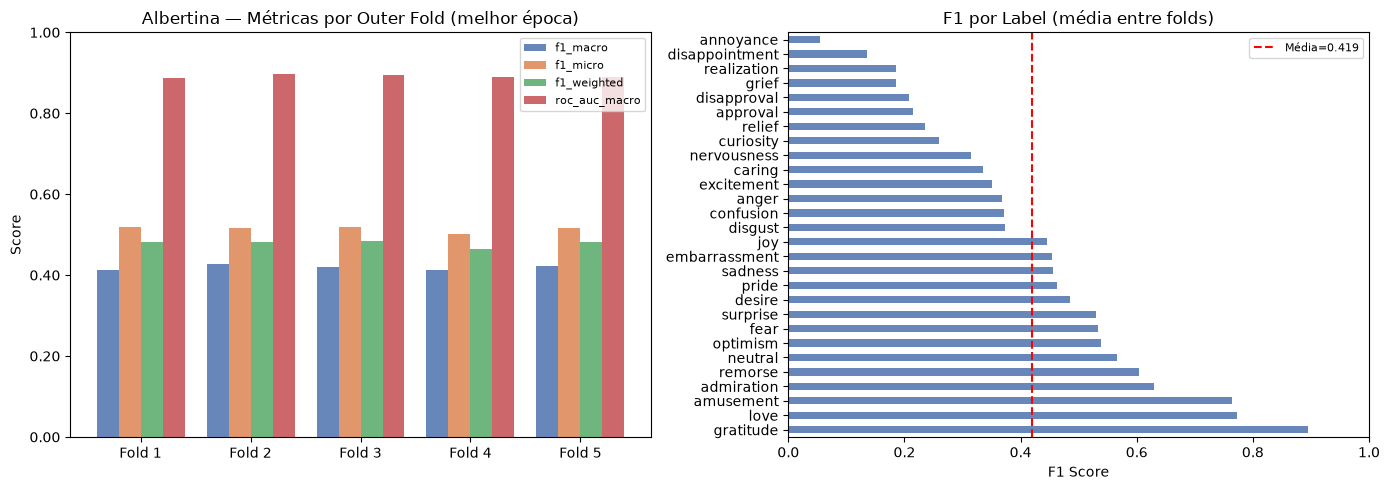

Figura salva em ..\data\out\albertina\albertina_metrics.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_plot = ["f1_macro", "f1_micro", "f1_weighted", "roc_auc_macro"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = axes[0]
x = np.arange(len(df_results))
width = 0.20
for i, (met, col) in enumerate(zip(metric_plot, colors)):
    ax.bar(x + i * width, df_results[met], width, label=met, color=col, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Fold {k}" for k in df_results.index])
ax.set_ylim(0, 1)
ax.set_title("Albertina — Métricas por Outer Fold (melhor época)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score")

ax2 = axes[1]
f1_per_label_mean.plot.barh(ax=ax2, color="#4C72B0", alpha=0.85)
ax2.set_title("F1 por Label (média entre folds)")
ax2.set_xlabel("F1 Score")
ax2.set_xlim(0, 1)
ax2.axvline(
    f1_per_label_mean.mean(), color="red", linestyle="--",
    label=f"Média={f1_per_label_mean.mean():.3f}"
)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "albertina_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'albertina_metrics.png'}")

In [14]:
# Métricas globais
df_results.to_csv(OUT_DIR / "albertina_global_metrics.csv")

# F1 por label
f1_per_label_folds.to_csv(OUT_DIR / "albertina_f1_per_label.csv")

# Resumo JSON
summary_dict = {
    "model": "Albertina 100M PT-BR (PORTULAN/albertina-100m-portuguese-ptbr-encoder)",
    "loss": "CrossBalancedLoss (beta=0.9999)",
    "optimizer": "AdamWeightDecay (lr=2e-5, wd=0.01)",
    "scheduler": "Polynomial decay + linear warmup (10%)",
    "strategy": f"Outer CV ({N_OUTER_FOLDS} folds), {NUM_EPOCHS} épocas",
    "n_labels": N_LABELS,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "f1_macro_mean": round(float(df_results["f1_macro"].mean()), 4),
    "f1_macro_std": round(float(df_results["f1_macro"].std()),  4),
    "f1_micro_mean": round(float(df_results["f1_micro"].mean()), 4),
    "f1_micro_std": round(float(df_results["f1_micro"].std()),  4),
    "roc_auc_mean": round(float(df_results["roc_auc_macro"].mean()), 4),
    "roc_auc_std": round(float(df_results["roc_auc_macro"].std()),  4),
}

with open(OUT_DIR / "albertina_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para:", OUT_DIR.resolve())
print(json.dumps(summary_dict, indent=2, ensure_ascii=False))

Arquivos exportados para: C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\albertina
{
  "model": "Albertina 100M PT-BR (PORTULAN/albertina-100m-portuguese-ptbr-encoder)",
  "loss": "CrossBalancedLoss (beta=0.9999)",
  "optimizer": "AdamWeightDecay (lr=2e-5, wd=0.01)",
  "scheduler": "Polynomial decay + linear warmup (10%)",
  "strategy": "Outer CV (5 folds), 6 épocas",
  "n_labels": 28,
  "max_len": 128,
  "batch_size": 32,
  "f1_macro_mean": 0.4189,
  "f1_macro_std": 0.0065,
  "f1_micro_mean": 0.514,
  "f1_micro_std": 0.0071,
  "roc_auc_mean": 0.8915,
  "roc_auc_std": 0.0037
}


## Testes Limiar

In [6]:
## Testes Limiar
# ══════════════════════════════════════════════════════════════════
# TESTES DE LIMIAR — baseline honesto do Albertina
# Não treina nada. Reaproveita as probabilidades OOF já geradas.
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import average_precision_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Caches de probabilidades OOF (gerados pelos notebooks do ensemble)
CACHE_V1 = Path("../data/out/ensemble_fuzzy/cache")
CACHE_V2 = Path("../data/out/ensemble_fuzzy_2/cache")

# Métricas do ensemble, para a comparação final
V1_METRICS = Path("../data/out/ensemble_fuzzy/ensemble_fuzzy_global_metrics.csv")
V2_METRICS = Path("../data/out/ensemble_fuzzy_2/ensemble_fuzzy2_global_metrics.csv")

# Saídas deste teste (separadas — não tocam em ../data/out/albertina)
OUT_LIMIAR = Path("../data/out/testes_limiar_albertina")
CACHE_LIMIAR = OUT_LIMIAR / "cache"
OUT_LIMIAR.mkdir(parents=True, exist_ok=True)
CACHE_LIMIAR.mkdir(parents=True, exist_ok=True)

# A MESMA grade usada em fit_fuzzy_emotion → comparação apples-to-apples
THRESH_GRID = np.linspace(0.05, 0.95, 19)
# Grade fina: só teste de robustez, NÃO é a comparação justa
THRESH_GRID_FINE = np.linspace(0.01, 0.99, 197)

FIXED_THRESHOLD = 0.5   # o que os baselines usam hoje

def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

Y_all = np.vstack([Y_folds[k] for k in folds_data])
base_rates = pd.Series(Y_all.mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")
print("Compare com o limiar 0.5 usado no baseline.")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)
Compare com o limiar 0.5 usado no baseline.


In [8]:
def find_cached(fname):
    for d in (CACHE_V1, CACHE_V2, CACHE_LIMIAR):
        fp = d / fname
        if fp.exists():
            return fp
    return None

def best_epoch_per_fold():
    fp = OUT_DIR / "albertina_global_metrics.csv"   # OUT_DIR = ../data/out/albertina
    if fp.exists():
        df = pd.read_csv(fp, index_col=0)
        if "epoch" in df.columns:
            return {int(f): int(e) for f, e in df["epoch"].items()}
    return None

def compute_albertina_oof(missing_folds):
    """Regenera P_Albertina a partir dos checkpoints (só se não houver cache)."""
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])

    _tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    _BATCH = 64

    class _AlbertinaForEmotions(nn.Module):
        # nomes de atributos idênticos ao baseline (compatibilidade com o state_dict)
        def __init__(self, model_name=MODEL_NAME, n_labels=N_LABELS, dropout=0.1):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name, dtype=torch.float32)
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
        def forward(self, input_ids, attention_mask):
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    best_eps = best_epoch_per_fold()

    def find_ckpt(fold):
        if best_eps and fold in best_eps:
            fp = CKPT_DIR / f"fold_{fold}_epoch_{best_eps[fold]:02d}.pt"
            if fp.exists():
                return fp
        cands = sorted(CKPT_DIR.glob(f"fold_{fold}_epoch_*.pt"))
        assert cands, f"Nenhum checkpoint para o fold {fold} em {CKPT_DIR}"
        best_fp, best_f1 = None, -1
        for fp in cands:
            ck = torch.load(fp, map_location="cpu", weights_only=False)
            f1 = ck.get("metrics", {}).get("f1_macro", -1)
            if f1 > best_f1:
                best_fp, best_f1 = fp, f1
            del ck
        return best_fp

    for k in missing_folds:
        t0 = time.time()
        ckpt_path = find_ckpt(k)
        print(f"  Fold {k}: {ckpt_path.name}")
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = _AlbertinaForEmotions().to(DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        model.eval()

        texts, probas = TEXT_folds[k].tolist(), []
        with torch.no_grad():
            for i in range(0, len(texts), _BATCH):
                enc = _tokenizer(texts[i:i + _BATCH], max_length=MAX_LEN,
                                 padding="max_length", truncation=True, return_tensors="pt")
                logits = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
                probas.append(torch.sigmoid(logits).cpu().numpy())
        np.save(CACHE_LIMIAR / f"P_ALBERTINA_fold_{k}.npy", np.vstack(probas))
        del model, ck
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  P_ALBERTINA fold {k} salvo ({time.time() - t0:.0f}s)")


missing = [k for k in folds_data if find_cached(f"P_ALBERTINA_fold_{k}.npy") is None]
if missing:
    print(f"Cache ausente → gerando P_Albertina para os folds {missing}...")
    compute_albertina_oof(missing)
else:
    print("P_Albertina encontrado em cache — nada será recalculado.")

P_Albertina_folds = {k: np.load(find_cached(f"P_ALBERTINA_fold_{k}.npy")) for k in folds_data}
print("P_Albertina OK:", {k: v.shape for k, v in P_Albertina_folds.items()})

# P_LR é opcional: só entra se já estiver em cache (não retreinamos LR aqui)
P_LR_folds = None
if all(find_cached(f"P_LR_fold_{k}.npy") is not None for k in folds_data):
    P_LR_folds = {k: np.load(find_cached(f"P_LR_fold_{k}.npy")) for k in folds_data}
    print("P_LR  OK:", {k: v.shape for k, v in P_LR_folds.items()})
else:
    print("P_LR não encontrado em cache → o LR fica fora desta análise.")
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 no conjunto de CALIBRAÇÃO.
    Mesma lógica de fit_fuzzy_emotion (vetorizada)."""
    thr = np.full(N_LABELS, 0.5)
    f1s = np.zeros(N_LABELS)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]     # (n, G)
        yb   = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        b = int(np.argmax(f1))
        thr[j], f1s[j] = float(grid[b]), float(f1[b])
    return thr, f1s

Cache ausente → gerando P_Albertina para os folds [1, 2, 3, 4, 5]...
  Fold 1: fold_1_epoch_06.pt


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1803.88it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_ALBERTINA fold 1 salvo (43s)
  Fold 2: fold_2_epoch_06.pt


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 2993.32it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_ALBERTINA fold 2 salvo (102s)
  Fold 3: fold_3_epoch_06.pt


...

  P_ALBERTINA fold 3 salvo (102s)
  Fold 4: fold_4_epoch_05.pt


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3000.55it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_ALBERTINA fold 4 salvo (43s)
  Fold 5: fold_5_epoch_06.pt


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 4493.56it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_ALBERTINA fold 5 salvo (50s)
P_Albertina OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}
P_LR  OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [9]:
def metrics_limiar(Y_true, Y_pred, Y_score, label_names):
    """Mesmas métricas do baseline + Average Precision (PR-AUC)."""
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_score[:, valid], average="macro")
        # PR-AUC: métrica de ranking apropriada sob desbalanceamento
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_score[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Funções prontas.")
results      = {}
results_fine = {}
thr_store    = {}

sources = {"Albertina": P_Albertina_folds}
if P_LR_folds is not None:
    sources["LR"] = P_LR_folds

for name in sources:
    results[f"{name}@0.5"] = []
    results[f"{name}@tuned"] = []
    results_fine[f"{name}@tuned_fine"] = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    print(f"\n{'='*62}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*62}")
    train_ks = [j for j in folds_data if j != outer_k]

    Y_cal = np.vstack([Y_folds[j] for j in train_ks])
    Y_te  = Y_folds[outer_k]
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {len(Y_te):>5}")

    thr_store[outer_k] = {}
    for name, P_folds in sources.items():
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF: nenhum modelo viu esses dados
        P_te  = P_folds[outer_k]

        # (a) limiar fixo 0.5 — o que o baseline reporta hoje
        m_fix = metrics_limiar(Y_te, (P_te >= FIXED_THRESHOLD).astype(int), P_te, EMOTION_COLS)
        m_fix["outer_fold"] = outer_k
        results[f"{name}@0.5"].append(m_fix)

        # (b) limiar calibrado por emoção — MESMA grade do Ensemble Fuzzy
        thr, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        m_tun = metrics_limiar(Y_te, (P_te >= thr[None, :]).astype(int), P_te, EMOTION_COLS)
        m_tun["outer_fold"] = outer_k
        results[f"{name}@tuned"].append(m_tun)
        thr_store[outer_k][name] = thr

        # (c) grade fina — robustez, NÃO é a comparação justa
        thr_f, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID_FINE)
        m_fine = metrics_limiar(Y_te, (P_te >= thr_f[None, :]).astype(int), P_te, EMOTION_COLS)
        m_fine["outer_fold"] = outer_k
        results_fine[f"{name}@tuned_fine"].append(m_fine)

        print(f"  {name:4s} @0.5       | F1={m_fix['f1_macro']:.4f} P={m_fix['precision_macro']:.4f} "
              f"R={m_fix['recall_macro']:.4f} AP={m_fix['avg_precision_macro']:.4f}")
        print(f"  {name:4s} @calibrado | F1={m_tun['f1_macro']:.4f} P={m_tun['precision_macro']:.4f} "
              f"R={m_tun['recall_macro']:.4f} AP={m_tun['avg_precision_macro']:.4f} "
              f"(limiar médio={thr.mean():.2f})")

print("\n✓ Concluído.")

Funções prontas.

  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  Albertina @0.5       | F1=0.4117 P=0.5692 R=0.3532 AP=0.4227
  Albertina @calibrado | F1=0.4605 P=0.4659 R=0.4740 AP=0.4227 (limiar médio=0.30)
  LR   @0.5       | F1=0.3695 P=0.3324 R=0.4560 AP=0.3390
  LR   @calibrado | F1=0.3790 P=0.3851 R=0.4025 AP=0.3390 (limiar médio=0.66)

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810
  Albertina @0.5       | F1=0.4274 P=0.5901 R=0.3669 AP=0.4408
  Albertina @calibrado | F1=0.4709 P=0.4617 R=0.4949 AP=0.4408 (limiar médio=0.28)
  LR   @0.5       | F1=0.3608 P=0.3172 R=0.4587 AP=0.3260
  LR   @calibrado | F1=0.3703 P=0.3660 R=0.3973 AP=0.3260 (limiar médio=0.66)

  OUTER FOLD 3/5
  Calibração:  43398 | Teste: 10836
  Albertina @0.5       | F1=0.4207 P=0.5649 R=0.3643 AP=0.4374
  Albertina @calibrado | F1=0.4692 P=0.4634 R=0.4892 AP=0.4374 (limiar médio=0.30)
  LR   @0.5       | F1=0.3663 P=0.3249 R=0.4729 AP=0.3487
  LR   @calibrado | F1=0.3830 P=0.3766 R=0.4315 AP=0.

In [10]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro",
            "f1_micro", "roc_auc_macro", "avg_precision_macro"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

dfs      = {name: folds_df(v) for name, v in results.items()}
dfs_fine = {name: folds_df(v) for name, v in results_fine.items()}

rows = []
for name, d in dfs.items():
    r = {"Configuração": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro",
              "f1_micro", "roc_auc_macro", "avg_precision_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(r)
df_thresh = pd.DataFrame(rows).set_index("Configuração")

print("===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====")
display(df_thresh)

for name in sources:
    d0, d1 = dfs[f"{name}@0.5"], dfs[f"{name}@tuned"]
    delta = d1["f1_macro"].mean() - d0["f1_macro"].mean()
    print(f"\n{name}: F1-macro {d0['f1_macro'].mean():.4f} → {d1['f1_macro'].mean():.4f} "
          f"({delta:+.4f}) — apenas calibrando o limiar")
    try:
        s, p = wilcoxon(d1["f1_macro"].values, d0["f1_macro"].values)
        print(f"     Wilcoxon pareado (n=5 folds): W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"     Wilcoxon não aplicável: {e}")

print("\n===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====")
display(pd.DataFrame([
    {"Configuração": name,
     **{c: f"{d[c].mean():.4f} ± {d[c].std():.4f}"
        for c in ["precision_macro", "recall_macro", "f1_macro", "f1_micro"]}}
    for name, d in dfs_fine.items()
]).set_index("Configuração"))
comp, fuzzy_f1 = [], {}

for name, d in dfs.items():
    comp.append({
        "Modelo": name,
        "precision_macro": d["precision_macro"].mean(),
        "recall_macro"   : d["recall_macro"].mean(),
        "f1_macro"       : d["f1_macro"].mean(),
        "f1_macro_std"   : d["f1_macro"].std(),
        "f1_micro"       : d["f1_micro"].mean(),
        "roc_auc_macro"  : d["roc_auc_macro"].mean(),
    })

for label, fp in [("Ensemble Fuzzy v1", V1_METRICS), ("Ensemble Fuzzy v2", V2_METRICS)]:
    if fp.exists():
        d = pd.read_csv(fp, index_col=0)
        comp.append({
            "Modelo": label,
            "precision_macro": d["precision_macro"].mean(),
            "recall_macro"   : d["recall_macro"].mean(),
            "f1_macro"       : d["f1_macro"].mean(),
            "f1_macro_std"   : d["f1_macro"].std(),
            "f1_micro"       : d["f1_micro"].mean(),
            "roc_auc_macro"  : d["roc_auc_macro"].mean(),
        })
        fuzzy_f1[label] = d["f1_macro"].values
    else:
        print(f"(aviso) {fp} não encontrado — {label} fora da comparação.")

df_final = pd.DataFrame(comp).set_index("Modelo").sort_values("f1_macro", ascending=False)
print("===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====")
display(df_final.round(4))
print(f"\nMelhor F1-macro: {df_final.index[0]} ({df_final['f1_macro'].iloc[0]:.4f})")

# Teste decisivo: Fuzzy v2 vs Albertina@calibrado
if "Ensemble Fuzzy v2" in fuzzy_f1:
    a = fuzzy_f1["Ensemble Fuzzy v2"]
    b = dfs["Albertina@tuned"]["f1_macro"].values
    print(f"\n----- Fuzzy v2 vs Albertina@calibrado (F1-macro por fold) -----")
    print(f"  Fuzzy v2       : {a.mean():.4f} ± {a.std():.4f}")
    print(f"  Albertina@calibrado : {b.mean():.4f} ± {b.std():.4f}")
    print(f"  Δ (fuzzy − Albertina): {a.mean() - b.mean():+.4f}")
    try:
        s, p = wilcoxon(a, b)
        print(f"  Wilcoxon: W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"  Wilcoxon não aplicável: {e}")
    print("\n  →", "O ensemble AINDA supera o baseline honesto → o fuzzy agrega valor real."
          if a.mean() > b.mean() else
          "O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.")
thr_mean = pd.DataFrame(
    {f"fold_{k}": thr_store[k]["Albertina"] for k in thr_store}, index=EMOTION_COLS
).mean(axis=1)

df_thr = pd.DataFrame({
    "limiar_calibrado": thr_mean,
    "base_rate": base_rates.reindex(EMOTION_COLS),
}).sort_values("base_rate")

===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Configuração,,,,,,,
Albertina@0.5,0.3891 ± 0.0076,0.5705 ± 0.0120,0.3615 ± 0.0055,0.4189 ± 0.0065,0.5141 ± 0.0071,0.8915 ± 0.0037,0.4308 ± 0.0078
Albertina@tuned,0.3421 ± 0.0041,0.4625 ± 0.0062,0.4866 ± 0.0103,0.4660 ± 0.0045,0.5419 ± 0.0041,0.8915 ± 0.0037,0.4308 ± 0.0078
LR@0.5,0.1873 ± 0.0088,0.3240 ± 0.0088,0.4652 ± 0.0075,0.3655 ± 0.0052,0.4152 ± 0.0054,0.8390 ± 0.0017,0.3362 ± 0.0092
LR@tuned,0.2422 ± 0.0071,0.3747 ± 0.0131,0.4119 ± 0.0136,0.3784 ± 0.0050,0.4690 ± 0.0020,0.8390 ± 0.0017,0.3362 ± 0.0092



Albertina: F1-macro 0.4189 → 0.4660 (+0.0470) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

LR: F1-macro 0.3655 → 0.3784 (+0.0129) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====


,precision_macro,recall_macro,f1_macro,f1_micro
Configuração,,,,
Albertina@tuned_fine,0.4554 ± 0.0054,0.4870 ± 0.0088,0.4635 ± 0.0035,0.5431 ± 0.0035
LR@tuned_fine,0.3739 ± 0.0118,0.4097 ± 0.0115,0.3777 ± 0.0039,0.4702 ± 0.0023


===== COMPARAÇÃO FINAL — todos com tratamento de limiar equivalente =====


,precision_macro,recall_macro,f1_macro,f1_macro_std,f1_micro,roc_auc_macro
Modelo,,,,,,
Albertina@tuned,0.4625,0.4866,0.4660,0.0045,0.5419,0.8915
Albertina@0.5,0.5705,0.3615,0.4189,0.0065,0.5141,0.8915
Ensemble Fuzzy v2,0.3724,0.5157,0.4139,0.0049,0.4834,0.8356
Ensemble Fuzzy v1,0.3465,0.5495,0.4008,0.0051,0.4457,0.8521
LR@tuned,0.3747,0.4119,0.3784,0.0050,0.4690,0.8390
LR@0.5,0.3240,0.4652,0.3655,0.0052,0.4152,0.8390



Melhor F1-macro: Albertina@tuned (0.4660)

----- Fuzzy v2 vs Albertina@calibrado (F1-macro por fold) -----
  Fuzzy v2       : 0.4139 ± 0.0044
  Albertina@calibrado : 0.4660 ± 0.0040
  Δ (fuzzy − Albertina): -0.0520
  Wilcoxon: W=0.0, p=0.0625

  → O baseline honesto SUPERA o ensemble → o ganho anterior era efeito de limiar.


===== LIMIAR CALIBRADO POR EMOÇÃO (Albertina, média entre folds) =====


,limiar_calibrado,base_rate
grief,0.15,0.0018
pride,0.42,0.0026
relief,0.37,0.0034
nervousness,0.31,0.0038
embarrassment,0.47,0.0069
remorse,0.29,0.0123
fear,0.30,0.0141
desire,0.46,0.0148
disgust,0.23,0.0187
excitement,0.27,0.0194



Limiar médio calibrado: 0.297 (vs 0.5 no baseline)
Emoções com limiar ótimo < 0.5: 27/28


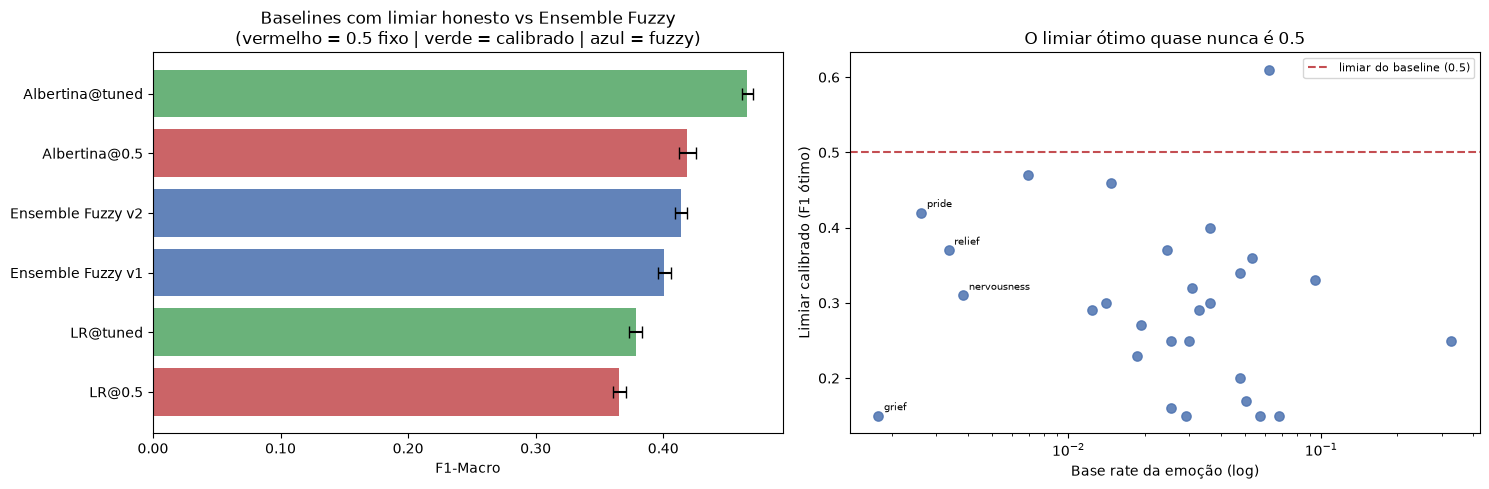

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\testes_limiar_albertina
{
  "objetivo": "Medir o Albertina com o MESMO tratamento de limiar que o Ensemble Fuzzy recebe (calibrado por emocao, OOF), em vez de 0.5 fixo.",
  "protocolo": "Para cada outer fold k: limiares calibrados por emocao nas probabilidades OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em P_Albertina[k]. Nenhum limiar escolhido no fold de teste.",
  "grade_justa": [
    0.05,
    0.95,
    19
  ],
  "nota_metrica": "ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e a metrica de ranking apropriada para labels raros.",
  "ressalva": "P_Albertina herda do baseline a selecao da melhor epoca pelo F1 no proprio fold de teste; como o Ensemble Fuzzy usa o mesmo P_Albertina, a comparacao relativa nao e afetada, mas o valor absoluto e levemente otimista.",
  "resultados": {
    "Albertina@0.5": {
      "f1_macro": "0.41

In [11]:
print("===== LIMIAR CALIBRADO POR EMOÇÃO (Albertina, média entre folds) =====")
display(df_thr.round(4))
print(f"\nLimiar médio calibrado: {thr_mean.mean():.3f} (vs 0.5 no baseline)")
print(f"Emoções com limiar ótimo < 0.5: {int((thr_mean < 0.5).sum())}/{N_LABELS}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
order = df_final.sort_values("f1_macro")
cols = ["#C44E52" if "@0.5" in i else ("#4C72B0" if "Fuzzy" in i else "#55A868")
        for i in order.index]
ax.barh(order.index, order["f1_macro"], xerr=order["f1_macro_std"],
        capsize=4, color=cols, alpha=0.88)
ax.set_xlabel("F1-Macro")
ax.set_title("Baselines com limiar honesto vs Ensemble Fuzzy\n"
             "(vermelho = 0.5 fixo | verde = calibrado | azul = fuzzy)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax2 = axes[1]
ax2.scatter(df_thr["base_rate"], df_thr["limiar_calibrado"], s=45, color="#4C72B0", alpha=0.85)
ax2.axhline(0.5, color="#C44E52", linestyle="--", label="limiar do baseline (0.5)")
ax2.set_xscale("log")
ax2.set_xlabel("Base rate da emoção (log)")
ax2.set_ylabel("Limiar calibrado (F1 ótimo)")
ax2.set_title("O limiar ótimo quase nunca é 0.5")
ax2.legend(fontsize=8)
for emo in df_thr.index[:4]:
    ax2.annotate(emo, (df_thr.loc[emo, "base_rate"], df_thr.loc[emo, "limiar_calibrado"]),
                 fontsize=7, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig(OUT_LIMIAR / "testes_limiar_albertina.png", dpi=150, bbox_inches="tight")
plt.show()
df_thresh.to_csv(OUT_LIMIAR / "efeito_limiar.csv")
df_final.to_csv(OUT_LIMIAR / "comparacao_final_limiar_honesto.csv")
df_thr.to_csv(OUT_LIMIAR / "limiares_calibrados_por_emocao.csv")
pd.DataFrame({name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
              for name, v in results.items()}).to_csv(OUT_LIMIAR / "f1_por_label_limiar.csv")
np.save(CACHE_LIMIAR / "thresholds_albertina.npy",
        np.vstack([thr_store[k]["Albertina"] for k in sorted(thr_store)]))

summary = {
    "objetivo": ("Medir o Albertina com o MESMO tratamento de limiar que o Ensemble Fuzzy "
                 "recebe (calibrado por emocao, OOF), em vez de 0.5 fixo."),
    "protocolo": ("Para cada outer fold k: limiares calibrados por emocao nas probabilidades "
                  "OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em "
                  "P_Albertina[k]. Nenhum limiar escolhido no fold de teste."),
    "grade_justa": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "nota_metrica": ("ROC-AUC e otimista sob desbalanceamento; Average Precision (PR-AUC) e "
                     "a metrica de ranking apropriada para labels raros."),
    "ressalva": ("P_Albertina herda do baseline a selecao da melhor epoca pelo F1 no proprio fold "
                 "de teste; como o Ensemble Fuzzy usa o mesmo P_Albertina, a comparacao relativa "
                 "nao e afetada, mas o valor absoluto e levemente otimista."),
    "resultados": {name: {
        "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
        "precision_macro": f"{d['precision_macro'].mean():.4f}",
        "recall_macro": f"{d['recall_macro'].mean():.4f}",
        "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
        "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
    } for name, d in dfs.items()},
    "limiar_medio_albertina": float(thr_mean.mean()),
    "n_emocoes_limiar_abaixo_0.5": int((thr_mean < 0.5).sum()),
}
with open(OUT_LIMIAR / "testes_limiar_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_LIMIAR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))